# 02 — Analyse globale du catalogue

**Question métier :** comment est composé le catalogue, et quels critères faut-il regarder avant une sélection de livres en français ?

Je pars de la table contrôlée. Le grain reste la fiche Goodreads, pas l'œuvre unique. Le volume de notes mesure un signal de visibilité associé à la fiche ; il ne donne ni les ventes ni la demande actuelle.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Le notebook fonctionne depuis son dossier ou depuis la racine du projet.
racine = Path.cwd()
if racine.name == 'notebooks':
    racine = racine.parent
dossier_sortie = racine / 'data/processed'
dossier_sortie.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 14)

import matplotlib.pyplot as plt

df = pd.read_csv(dossier_sortie / 'livres.csv', sep=';', dtype={'ISBN': 'string'}, low_memory=False)
plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

## 1. Poser les KPI

La note moyenne donne le même poids à chaque fiche ayant une note exploitable. La médiane du nombre de notes inclut les fiches à zéro note. La part avec au moins 100 notes se calcule sur toutes les fiches conservées.

In [2]:
kpi = pd.DataFrame({
    'NbFiches': [len(df)],
    'NbFichesNoteExploitable': [df['NoteExploitable'].sum()],
    'NoteMoyenneFiches': [df['Note'].mean()],
    'NoteMedianeFiches': [df['Note'].median()],
    'MedianeNbNotes': [df['NbNotes'].median()],
    'PartAvec100NotesPct': [df['NbNotes'].ge(100).mean() * 100],
    'PartLangueAbsentePct': [df['LangueAbsente'].mean() * 100],
    'NbFichesFrancais': [df['Langue'].eq('Français').sum()]
})
display(kpi.round(2).T)
kpi.to_csv(dossier_sortie / 'controle_kpi.csv', index=False, sep=';', encoding='utf-8-sig')

,0
NbFiches,1850032.00
NbFichesNoteExploitable,1398254.00
NoteMoyenneFiches,3.83
NoteMedianeFiches,3.89
MedianeNbNotes,5.00
PartAvec100NotesPct,18.50
PartLangueAbsentePct,86.40
NbFichesFrancais,16327.00


## 2. Comprendre la composition par langue

Les langues absentes restent visibles. Les parts décrivent uniquement les fiches de ce dataset, pas l'ensemble du marché du livre. Les sous-groupes ne sont pas tirés au hasard.

,NbFiches,NbFichesNotees,NoteMoyenne,NoteMediane,MedianeNbNotes,PartPagesAbsentes,PartCataloguePct,PartFichesNoteesPct
Langue,,,,,,,,
Non renseignée,1598339,1156174,3.82,3.89,3.0,0.01,86.40,72.34
Anglais,209543,202926,3.87,3.91,159.0,0.01,11.33,96.84
Français,16327,15317,3.82,3.87,100.0,0.00,0.88,93.81
Allemand,11470,10306,3.82,3.88,109.0,0.00,0.62,89.85
Espagnol,7245,6890,3.85,3.90,419.0,0.00,0.39,95.10
Autre langue,3487,3186,3.88,3.92,74.0,0.00,0.19,91.37
Japonais,2059,2006,4.10,4.18,246.0,0.00,0.11,97.43
Italien,1156,1074,3.81,3.86,484.5,0.00,0.06,92.91
Portugais,406,375,3.88,3.96,218.5,0.00,0.02,92.36


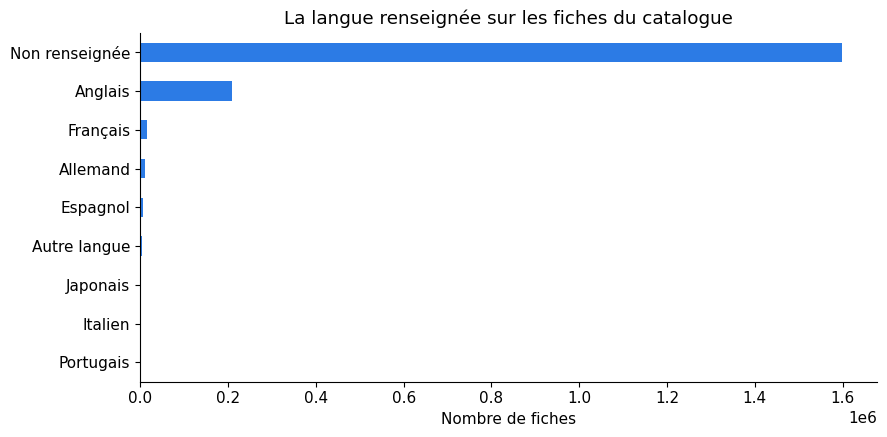

In [3]:
par_langue = df.groupby('Langue', dropna=False).agg(
    NbFiches=('IdLivre', 'size'),
    NbFichesNotees=('Note', 'count'),
    NoteMoyenne=('Note', 'mean'),
    NoteMediane=('Note', 'median'),
    MedianeNbNotes=('NbNotes', 'median'),
    PartPagesAbsentes=('PagesAbsentes', 'mean')
)
par_langue['PartCataloguePct'] = par_langue['NbFiches'] / len(df) * 100
par_langue['PartFichesNoteesPct'] = par_langue['NbFichesNotees'] / par_langue['NbFiches'] * 100
display(par_langue.sort_values('NbFiches', ascending=False).round(2))

par_langue['NbFiches'].sort_values().plot.barh(color='#2C7BE5')
plt.title('La langue renseignée sur les fiches du catalogue')
plt.xlabel('Nombre de fiches')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 3. Distinguer la note et le nombre de notations

Une fiche notée 5/5 par une personne n'apporte pas le même recul qu'une fiche notée 4/5 avec 1 000 notations. Le seuil de 100 est un critère de sélection à discuter, pas une garantie statistique.

**Lecture du tableau précédent :** la catégorie « Non renseignée » domine avec 1 598 339 fiches. Je trouve 16 327 fiches explicitement en français, sans pouvoir mesurer toutes celles dont la langue française serait absente.

,NbFiches,NoteMediane,NbFichesNotees,PartCataloguePct
TrancheNotes,,,,
0 note,451777,NaN,0,24.42
1-99,1055965,3.88,1055965,57.08
100-999,197794,3.88,197794,10.69
1 000-9 999,95952,3.94,95952,5.19
10 000 et plus,48543,3.99,48543,2.62
Non renseigné,1,NaN,0,0.00


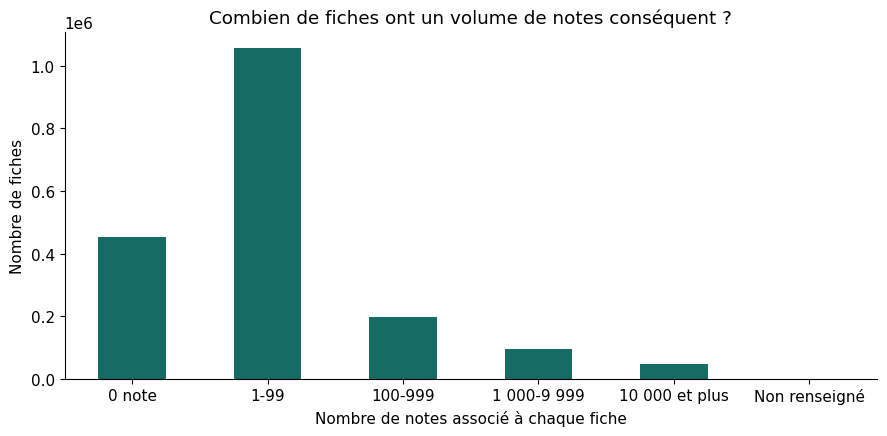

Fiches à 5/5 avec moins de 100 notes : 79824
Fiches à 5/5 avec au moins 100 notes : 0


In [4]:
ordre_notes = ['0 note', '1-99', '100-999', '1 000-9 999', '10 000 et plus', 'Non renseigné']
par_volume = df.groupby('TrancheNotes').agg(
    NbFiches=('IdLivre', 'size'), NoteMediane=('Note', 'median'),
    NbFichesNotees=('Note', 'count')
).reindex(ordre_notes)
par_volume['PartCataloguePct'] = par_volume['NbFiches'] / len(df) * 100
display(par_volume.round(2))

par_volume['NbFiches'].plot.bar(color='#176B65', rot=0)
plt.title('Combien de fiches ont un volume de notes conséquent ?')
plt.ylabel('Nombre de fiches')
plt.xlabel('Nombre de notes associé à chaque fiche')
plt.tight_layout()
plt.show()

print('Fiches à 5/5 avec moins de 100 notes :',
      (df['Note'].eq(5) & df['NbNotes'].lt(100)).sum())
print('Fiches à 5/5 avec au moins 100 notes :',
      (df['Note'].eq(5) & df['NbNotes'].ge(100)).sum())

## 4. Observer le format et la période renseignée

Les années décrivent les publications présentes dans l'extraction, pas une évolution des ventes ou des notes. La pagination absente reste un groupe séparé. Je ne retire pas les très gros recueils uniquement parce qu'ils sont rares.

**Lecture du volume :** seulement 18,50 % des fiches ont au moins 100 notations. Les 79 824 fiches à 5/5 ont toutes moins de 100 notations. Je ne construis donc pas ma sélection à partir de la note seule.

,NbFiches,NoteMediane,MedianeNbNotes
TranchePages,,,
1-150,476153,3.91,3.0
151-300,749230,3.86,5.0
301-600,520424,3.90,8.0
601 et plus,93053,4.00,5.0
Non renseigné,11172,3.90,294.0


,NbFiches,NoteMediane,MedianeNbNotes
PeriodePublication,,,
Avant 1950,2850,4.00,5.0
1950-1979,94506,3.94,2.0
1980-1999,787250,3.91,3.0
2000-2009,942554,3.88,8.0
2010-2020,22800,3.97,5.0
Non renseignée,72,3.73,0.0


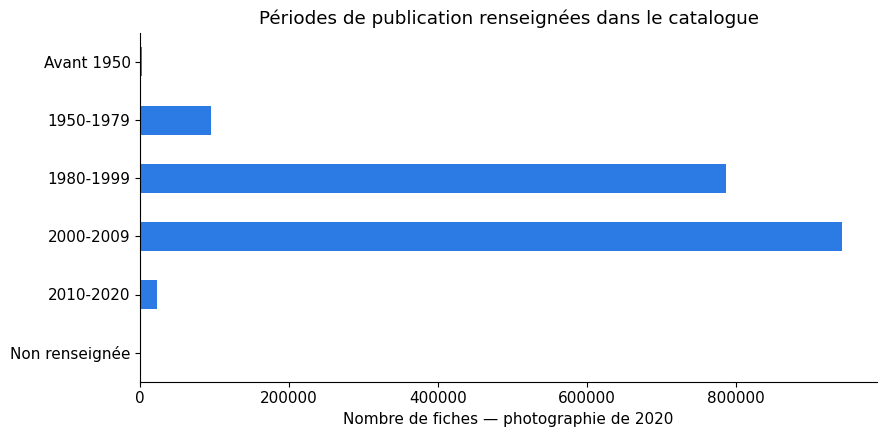

In [5]:
par_pages = df.groupby('TranchePages').agg(
    NbFiches=('IdLivre', 'size'), NoteMediane=('Note', 'median'),
    MedianeNbNotes=('NbNotes', 'median')
).reindex(['1-150', '151-300', '301-600', '601 et plus', 'Non renseigné'])
display(par_pages.round(2))

par_periode = df.groupby('PeriodePublication').agg(
    NbFiches=('IdLivre', 'size'), NoteMediane=('Note', 'median'),
    MedianeNbNotes=('NbNotes', 'median')
).reindex(['Avant 1950', '1950-1979', '1980-1999', '2000-2009', '2010-2020', 'Non renseignée'])
display(par_periode.round(2))
par_periode['NbFiches'].plot.barh(color='#2C7BE5')
plt.title('Périodes de publication renseignées dans le catalogue')
plt.xlabel('Nombre de fiches — photographie de 2020')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Lire les notes élevées avec leur effectif

Je compare la proportion de fiches à au moins 4/5 par tranche de volume. Le dénominateur est le nombre de fiches ayant une note exploitable dans chaque tranche. Ce résultat reste descriptif : les lecteurs choisissent les livres qu'ils évaluent.

,NbFichesNotees,PartAuMoins4Pct,NoteMediane
TrancheNotes,,,
1-99,1055965,45.32,3.88
100-999,197794,34.83,3.88
1 000-9 999,95952,41.20,3.94
10 000 et plus,48543,49.52,3.99


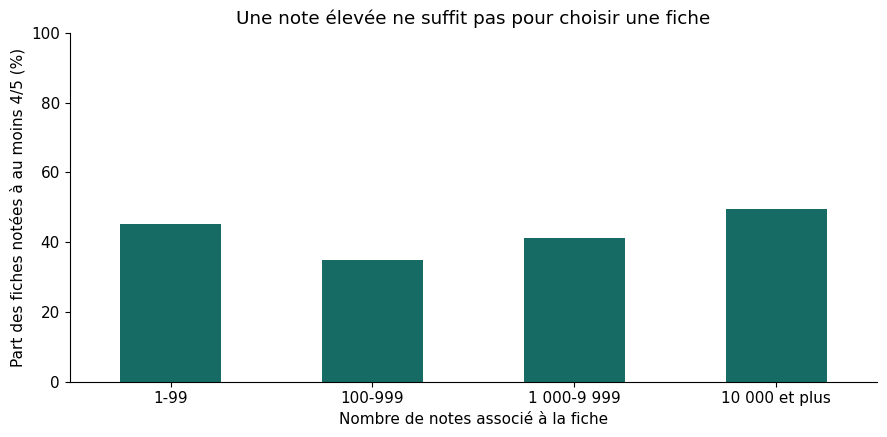

In [6]:
df_notes = df.loc[df['NoteExploitable']].copy()
df_notes['NoteAuMoins4'] = df_notes['Note'].ge(4)
comparaison = df_notes.groupby('TrancheNotes').agg(
    NbFichesNotees=('IdLivre', 'size'), PartAuMoins4=('NoteAuMoins4', 'mean'),
    NoteMediane=('Note', 'median')
).reindex(ordre_notes[1:-1])
comparaison['PartAuMoins4Pct'] = comparaison['PartAuMoins4'] * 100
display(comparaison[['NbFichesNotees', 'PartAuMoins4Pct', 'NoteMediane']].round(2))
comparaison['PartAuMoins4Pct'].plot.bar(color='#176B65', rot=0)
plt.title('Une note élevée ne suffit pas pour choisir une fiche')
plt.ylabel('Part des fiches notées à au moins 4/5 (%)')
plt.ylim(0, 100)
plt.xlabel('Nombre de notes associé à la fiche')
plt.tight_layout()
plt.show()

## 6. Préparer l'approfondissement

La mission cible des livres en français. Je sélectionne donc ce groupe pour la suite, et je garde les autres langues pour situer le périmètre. Je vais examiner les fiches avec une note exploitable d'au moins 4/5 et au moins 100 notations, puis vérifier la sensibilité à ces seuils.

Je ne retiendrai pas automatiquement les plus populaires. Une fiche devra aussi être documentée, et les éditions répétées demanderont une vérification avant toute mise en avant.

In [7]:
francais = df.loc[df['Langue'].eq('Français')]
print('Fiches en français :', len(francais))
print('Note >= 4 et au moins 100 notes :',
      (francais['Note'].ge(4) & francais['NbNotes'].ge(100)).sum())
print('Pagination absente en français (%) :', round(francais['PagesAbsentes'].mean() * 100, 2))
print('Editeur absent en français (%) :', round(francais['EditeurAbsent'].mean() * 100, 2))

assert par_langue['NbFiches'].sum() == len(df)
assert par_volume['NbFiches'].sum() == len(df)
assert par_pages['NbFiches'].sum() == len(df)
assert par_periode['NbFiches'].sum() == len(df)
print('Contrôles des regroupements : OK')

Fiches en français : 16327
Note >= 4 et au moins 100 notes : 3104
Pagination absente en français (%) : 0.02
Editeur absent en français (%) : 3.79
Contrôles des regroupements : OK


Les résultats et leur interprétation sont repris dans [Analyse.md](../docs/Analyse.md). Suite : [analyse approfondie](03_analyse_approfondie.ipynb).

**Ce que je retiens :** la note moyenne est de 3,83/5, mais le nombre médian de notations n'est que de 5. Le périmètre français contient 3 104 fiches à au moins 4/5 et 100 notations, avant les critères de métadonnées. Je vais vérifier ces fiches plus précisément.